# 03 — EDA and forecast-series selection

This notebook defines two datasets without mixing statistical concepts:

- **Dataset A:** the official ATP national vacancy target plus four non-total major-region targets, used by notebook 04.
- **Dataset B:** quality-filtered KEHA vacancy-count series, used only to construct panel examples in notebook 05.

ATP and KEHA targets retain separate `series_family` labels. Selection is deterministic and configured in `configs/eval.yaml`. The output is `data/processed/selected_series.csv`.

**Setup code:** imports the required libraries, locates the project folders, creates the report directories, loads the shared evaluation settings, and fixes the random seed so results are reproducible.

In [1]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import yaml

def _find_repo():
    env = os.environ.get("JOBAI_REPO")
    if env:
        return Path(env).resolve()
    p = Path.cwd().resolve()
    for candidate in (p, *p.parents):
        if (candidate / "configs" / "eval.yaml").is_file():
            return candidate
    return p

REPO = _find_repo()
PRO = REPO / "data" / "processed"
REPORTS = REPO / "reports"
FIGURES = REPORTS / "figures"
REPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
EVAL = yaml.safe_load((REPO / "configs" / "eval.yaml").read_text())
SEL = EVAL["panel_selection"]
SEED = int(EVAL["seed"])
np.random.seed(SEED)
print("repo:", REPO)
print("selection thresholds:", SEL)

repo: /Users/Alan/Documents/Study/MLProject-JobAI
selection thresholds: {'minimum_non_null_quarters': 48, 'maximum_zero_fraction': 0.5, 'minimum_variance': 1e-12, 'target_tables': ['12tu', '12tw'], 'target_contentscodes': {'12tu': ['AVPAIKATYHT'], '12tw': ['AVPAIKATLOPUSSA']}}


## Preflight and normalized-data inventory

**What this code does:** confirms that all five normalized CSV files and the notebook 02 assertion report exist and passed validation. It then displays their sizes and quarterly coverage before EDA begins.

In [2]:
required_tables = ["11l1", "11n1", "12tu", "12tw", "12r5"]
assertion_path = PRO / "normalization_assertions.json"
assert assertion_path.is_file(), "Run notebook 02 first: normalization_assertions.json is missing"
normalization_checks = json.loads(assertion_path.read_text())
for table_id in required_tables:
    assert (PRO / f"{table_id}__normalized.csv").is_file(), f"Missing normalized table: {table_id}"
    assert normalization_checks[table_id]["status"] == "passed", f"Notebook 02 checks did not pass for {table_id}"
inventory = pd.DataFrame([
    {"table_id": tid, **normalization_checks[tid]} for tid in required_tables
])[["table_id", "n_rows", "n_series", "n_quarters", "time_first", "time_last"]]
display(inventory)

,table_id,n_rows,n_series,n_quarters,time_first,time_last
0,11l1,270,5,54,2013Q1,2026Q2
1,11n1,270,5,54,2013Q1,2026Q2
2,12tu,129600,2400,54,2013Q1,2026Q2
3,12tw,408240,7560,54,2013Q1,2026Q2
4,12r5,8820,126,70,2009Q1,2026Q2


## Dataset A — official benchmark targets

The `11n1` whole-country row is excluded because it duplicates the `11l1/atp_lkm` national target.

**Selection-helper code:** loads the quality thresholds and defines reusable functions that create a unique series ID and summarize one series' completeness, zero frequency, variation, coverage, and selection result.

In [3]:
MIN_NON_NULL = int(SEL["minimum_non_null_quarters"])
MAX_ZERO = float(SEL["maximum_zero_fraction"])
MIN_VARIANCE = float(SEL["minimum_variance"])

def series_identifier(table_id, dimensions):
    return table_id + "::" + "|".join(f"{k}={dimensions[k]}" for k in dimensions)

def summarize_group(table_id, family, role, dimensions, frame, force_selected=None, force_reason=""):
    values = pd.to_numeric(frame["value"], errors="coerce")
    valid = values.dropna()
    n_periods = int(frame["timeperiod_q"].nunique())
    n_non_null = int(valid.size)
    zero_fraction = float((valid == 0).mean()) if n_non_null else 1.0
    variance = float(valid.var(ddof=0)) if n_non_null else 0.0
    reasons = []
    if n_non_null < MIN_NON_NULL:
        reasons.append("insufficient_non_null_quarters")
    if zero_fraction > MAX_ZERO:
        reasons.append("mostly_zero")
    if not np.isfinite(variance) or variance <= MIN_VARIANCE:
        reasons.append("no_variation")
    selected = not reasons if force_selected is None else bool(force_selected)
    reason = force_reason if force_selected is not None else ("accepted" if selected else ";".join(reasons))
    return {
        "table_id": table_id, "series_family": family, "role": role,
        "series_id": series_identifier(table_id, dimensions),
        "dimensions_json": json.dumps(dimensions, ensure_ascii=False, sort_keys=True),
        "n_periods": n_periods, "n_non_null": n_non_null,
        "coverage_ratio": n_non_null / n_periods if n_periods else 0.0,
        "zero_fraction": zero_fraction, "variance": variance,
        "time_first": frame["timeperiod_q"].min(), "time_last": frame["timeperiod_q"].max(),
        "selected": selected, "selection_reason": reason,
    }

### Select the official benchmark series

**What this code does:** loads the national `11l1` total-vacancy series and the regional `11n1` series. It keeps one national target and four major-region targets, while marking the duplicate whole-country row from `11n1` as excluded. The final assertion confirms that Dataset A contains exactly five selected benchmark series.

In [4]:
catalog_rows = []
national = pd.read_csv(PRO / "11l1__normalized.csv", low_memory=False)
national = national[national["contentscode"] == "atp_lkm"].copy()
catalog_rows.append(summarize_group("11l1", "ATP_official", "benchmark_target", {"contentscode": "atp_lkm"}, national, True, "accepted_official_national"))

regional = pd.read_csv(PRO / "11n1__normalized.csv", low_memory=False)
for (region, content), group in regional.groupby(["alue_16_20180101", "contentscode"], sort=True, dropna=False):
    is_total = region == "SSS"
    catalog_rows.append(summarize_group(
        "11n1", "ATP_official", "excluded_duplicate" if is_total else "benchmark_target",
        {"alue_16_20180101": str(region), "contentscode": str(content)}, group,
        not is_total, "duplicate_of_11l1_national" if is_total else "accepted_official_region",
    ))
benchmark = pd.DataFrame(catalog_rows)
assert int(((benchmark["role"] == "benchmark_target") & benchmark["selected"]).sum()) == 5
display(benchmark[["series_id", "role", "n_non_null", "selected", "selection_reason"]])

,series_id,role,n_non_null,selected,selection_reason
0,11l1::contentscode=atp_lkm,benchmark_target,54,True,accepted_official_national
1,11n1::alue_16_20180101=SA1|contentscode=atp_lkm,benchmark_target,54,True,accepted_official_region
2,11n1::alue_16_20180101=SA2|contentscode=atp_lkm,benchmark_target,54,True,accepted_official_region
3,11n1::alue_16_20180101=SA3|contentscode=atp_lkm,benchmark_target,54,True,accepted_official_region
4,11n1::alue_16_20180101=SA4|contentscode=atp_lkm,benchmark_target,54,True,accepted_official_region
5,11n1::alue_16_20180101=SSS|contentscode=atp_lkm,excluded_duplicate,54,False,duplicate_of_11l1_national


### Plot Dataset A over time

**What this code does:** combines the selected national and regional target rows for visualization, draws one quarterly line per target, displays the chart inline, and saves a PNG copy in the reports figures folder. The chart helps reveal gaps, unusual jumps, and differences in scale or movement across targets.

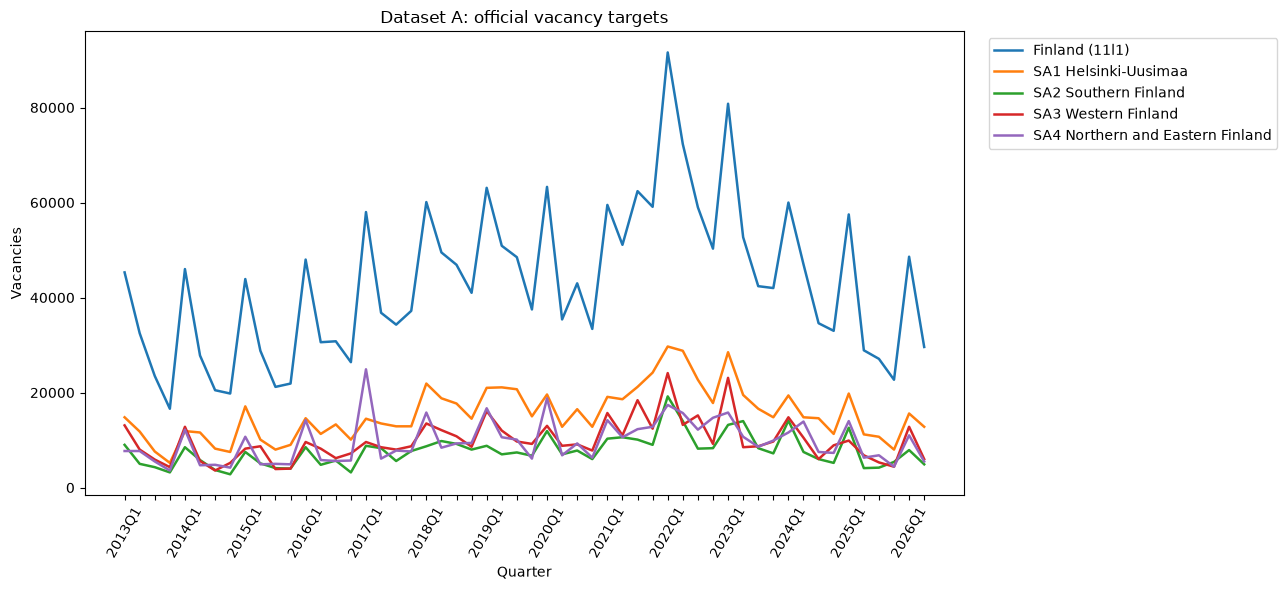

In [5]:
plot_frames = [national.assign(series_label="Finland (11l1)")]
for region, group in regional[regional["alue_16_20180101"] != "SSS"].groupby("alue_16_20180101_text"):
    plot_frames.append(group.assign(series_label=region))
plot_data = pd.concat(plot_frames, ignore_index=True)
fig, ax = plt.subplots(figsize=(13, 6))
for label, group in plot_data.groupby("series_label"):
    ax.plot(group["timeperiod_q"], group["value"], label=label, linewidth=1.8)
ax.set(title="Dataset A: official vacancy targets", xlabel="Quarter", ylabel="Vacancies")
ax.tick_params(axis="x", rotation=60)
for index, label in enumerate(ax.get_xticklabels()):
    label.set_visible(index % 4 == 0)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES / "03_dataset_a_targets.png", dpi=150, bbox_inches="tight")
plt.show()

## Dataset B — KEHA panel candidates

For `12tu`, only vacancy counts at total labour-market status are candidates; this avoids repeating the same vacancy concept across status categories. For `12tw`, only vacancy counts are targets. Duration is not treated as a count target. `12r5` series are retained as auxiliary-feature candidates.

**Panel-selection code:** loads each KEHA table, separates it into individual series, applies the shared quality rules, saves the complete selected-series catalog, and checks whether enough panel targets exist to permit fine-tuning.

In [6]:
tu = pd.read_csv(PRO / "12tu__normalized.csv", low_memory=False)
tu = tu[(tu["contentscode"] == "AVPAIKATYHT") & (tu["Työmarkkina-asema"] == "SSS")].copy()
for keys, group in tu.groupby(["Alue", "Ammattiryhmä", "Työmarkkina-asema", "contentscode"], sort=True, dropna=False):
    dims = dict(zip(["Alue", "Ammattiryhmä", "Työmarkkina-asema", "contentscode"], map(str, keys)))
    catalog_rows.append(summarize_group("12tu", "KEHA_occupation", "panel_target", dims, group))
del tu

tw = pd.read_csv(PRO / "12tw__normalized.csv", low_memory=False)
tw = tw[tw["contentscode"] == "AVPAIKATLOPUSSA"].copy()
tw_dims = ["Alue", "Toimiala", "Työnantajan sektori", "Työpaikan työn kesto", "contentscode"]
for keys, group in tw.groupby(tw_dims, sort=True, dropna=False):
    dims = dict(zip(tw_dims, map(str, keys)))
    catalog_rows.append(summarize_group("12tw", "KEHA_industry", "panel_target", dims, group))
del tw

r5 = pd.read_csv(PRO / "12r5__normalized.csv", low_memory=False)
for keys, group in r5.groupby(["Alue", "contentscode"], sort=True, dropna=False):
    dims = dict(zip(["Alue", "contentscode"], map(str, keys)))
    catalog_rows.append(summarize_group("12r5", "KEHA_regional_context", "auxiliary_feature", dims, group))

catalog = pd.DataFrame(catalog_rows).sort_values(["role", "table_id", "series_id"]).reset_index(drop=True)
catalog_path = PRO / "selected_series.csv"
catalog.to_csv(catalog_path, index=False)
selected_panel = catalog[(catalog["role"] == "panel_target") & catalog["selected"]]
minimum_panel_series = int(EVAL["finetuning_gate"]["minimum_selected_panel_series"])
series_gate_passed = len(selected_panel) >= minimum_panel_series
print("selected-series catalog:", catalog_path)
print("selected benchmark targets:", int(((catalog.role == "benchmark_target") & catalog.selected).sum()))
print("selected panel targets:", len(selected_panel))
print("fine-tuning series gate:", "PASS" if series_gate_passed else f"FAIL ({len(selected_panel)} < {minimum_panel_series})")
if not series_gate_passed:
    print("decision: keep Dataset B for analysis and classical experiments; do not fine-tune an LLM")

selected-series catalog: /Users/Alan/Documents/Study/MLProject-JobAI/data/processed/selected_series.csv
selected benchmark targets: 5
selected panel targets: 44
fine-tuning series gate: FAIL (44 < 100)


### Summarize and visualize the selection decision

**What this code does:** groups the catalog by table, role, selection result, and reason; displays the counts; plots accepted-series counts and rejection reasons; and saves the diagnostic figure. This makes it clear which tables contributed usable series and why other candidates were rejected.

,table_id,role,selected,selection_reason,n_series
0,11l1,benchmark_target,True,accepted_official_national,1
1,11n1,benchmark_target,True,accepted_official_region,4
2,11n1,excluded_duplicate,False,duplicate_of_11l1_national,1
3,12r5,auxiliary_feature,False,mostly_zero,4
4,12r5,auxiliary_feature,False,mostly_zero;no_variation,8
5,12r5,auxiliary_feature,True,accepted,114
6,12tu,panel_target,False,insufficient_non_null_quarters,87
7,12tu,panel_target,False,insufficient_non_null_quarters;mostly_zero,112
8,12tu,panel_target,False,insufficient_non_null_quarters;mostly_zero;no_...,96
9,12tu,panel_target,False,mostly_zero,16


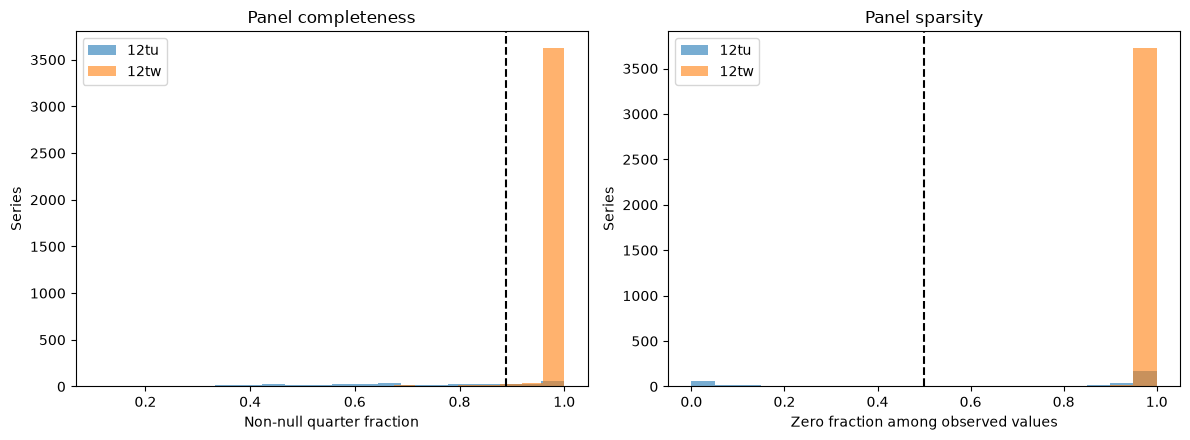

In [7]:
summary = (catalog.groupby(["table_id", "role", "selected", "selection_reason"], dropna=False)
           .size().rename("n_series").reset_index())
summary_path = REPORTS / "series_selection_summary.csv"
summary.to_csv(summary_path, index=False)
display(summary)

panel_candidates = catalog[catalog["role"] == "panel_target"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for table_id, group in panel_candidates.groupby("table_id"):
    axes[0].hist(group["coverage_ratio"], bins=20, alpha=0.6, label=table_id)
    axes[1].hist(group["zero_fraction"], bins=20, alpha=0.6, label=table_id)
axes[0].axvline(MIN_NON_NULL / 54, color="black", linestyle="--")
axes[1].axvline(MAX_ZERO, color="black", linestyle="--")
axes[0].set(title="Panel completeness", xlabel="Non-null quarter fraction", ylabel="Series")
axes[1].set(title="Panel sparsity", xlabel="Zero fraction among observed values", ylabel="Series")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "03_panel_selection_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## Selection contract

Notebook 04 must use only selected `benchmark_target` rows. Notebook 05 must use only selected `panel_target` rows. Rejected series remain in the catalog with an explicit reason so the decision is auditable.

The current panel-series gate is an evidence check, not a target to force. If fewer than the configured minimum are accepted, Dataset B remains useful for panel analysis and classical experiments, but it is not approved for LLM fine-tuning. Do not expand the selection or lower the threshold solely to turn `FAIL` into `PASS`; add new data only through a separately justified project decision.